In [4]:
%pip install pandas kagglehub

Note: you may need to restart the kernel to use updated packages.


### Задание 1 (синтаксис)

Для каждого покупателя получите таблицу со столбцами:

- `preferred_payment` — самый частый метод оплаты (при ничьей зафиксируйте правило, например lexicographically первый);
- `total_spent` — сумма всех трат;
- `addons_spent` — сумма на дополнительные услуги и аксессуары;
- `orders_count` — число заказов.

Отсортируйте по `total_spent` по убыванию и выведите топ-10.

#### Пример работы программы

**Output:**

```text
  customer_id  preferred_payment  total_spent  addons_spent  orders_count
0        C042        Credit Card     15420.50        890.00             7
1        C018             PayPal     14810.00        450.00             5
2        C103         Debit Card     13990.25       1200.00             6
...
```

#### Пограничные случаи

- Покупатель с одним заказом — `orders_count = 1`, `preferred_payment` — единственный метод.
- Два метода оплаты с одинаковой частотой — выберите один по зафиксированному правилу (укажите его в комментарии к коду).
- Покупатель без доп. услуг/аксессуаров — `addons_spent = 0`.
- Пропуски в сумме или методе оплаты — обработайте (отфильтруйте или заполните) и кратко опишите решение в комментарии.

### Решение

In [5]:
import kagglehub
import pandas as pd


# Download dataset
dataset = 'cameronseamons/electronic-sales-sep2023-sep2024'
data_dir = kagglehub.dataset_download(
    dataset,
    output_dir="data"
)

path = "data/Electronic_sales_Sep2023-Sep2024.csv"

print("Path to dataset files:", path)

/Users/annv0r0/Documents/work/IT/git_projects/TESTS/de/python/Python_1/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: data/Electronic_sales_Sep2023-Sep2024.csv


In [6]:
# customer_id  preferred_payment  total_spent  addons_spent  orders_count
df = pd.read_csv(path)
print(df)

       Customer ID  Age  Gender Loyalty Member Product Type      SKU  Rating  \
0             1000   53    Male             No   Smartphone  SKU1004       2   
1             1000   53    Male             No       Tablet  SKU1002       3   
2             1002   41    Male             No       Laptop  SKU1005       3   
3             1002   41    Male            Yes   Smartphone  SKU1004       2   
4             1003   75    Male            Yes   Smartphone  SKU1001       5   
...            ...  ...     ...            ...          ...      ...     ...   
19995        19996   27  Female             No   Smartphone   SMP234       4   
19996        19996   27  Female            Yes       Laptop   LTP123       4   
19997        19996   27  Female             No   Headphones   HDP456       4   
19998        19997   27    Male             No   Headphones   HDP456       1   
19999        19998   27     NaN            Yes       Laptop   LTP123       4   

      Order Status Payment Method  Tota

In [7]:
customer_spends_orders = df.groupby('Customer ID').agg(
    total_spent=('Total Price', 'sum'),
    orders_count=('Customer ID', 'size')    
).reset_index(names='customer_id')

preferred_payment = (
    df.groupby('Customer ID')['Payment Method']
# в случае нескольких методов оплаты с одинаковой частотой - выбрать первый по алфавиту
      .agg(lambda x: x.mode().sort_values().iloc[0])
      .rename_axis('customer_id')
      .reset_index(name='preferred_payment')
)

# df['Product Type'].unique() -> ['Smartphone', 'Tablet', 'Laptop', 'Smartwatch', 'Headphones']
# только наушники относятся к аксессуарам 

addons_spent = (
    df[df['Product Type'] == 'Headphones']
    .groupby('Customer ID')['Total Price'].sum()
    .reset_index(name='addons_spent')
    .rename(columns={'Customer ID': 'customer_id'})
)

result = (
    customer_spends_orders
    .merge(preferred_payment, on='customer_id', how='left')
    .merge(addons_spent, on='customer_id', how='left')
)

# Если есть пропуски - 0 или Unknown
result['addons_spent'] = result['addons_spent'].fillna(0)
result['total_spent'] = result['total_spent'].fillna(0)
result['preferred_payment'] = result['preferred_payment'].fillna('Unknown')

result = result[
    ['customer_id', 'preferred_payment', 'total_spent', 'addons_spent', 'orders_count']
].sort_values(by='total_spent', ascending=False).head(10)

result

,customer_id,preferred_payment,total_spent,addons_spent,orders_count
9728,16357,Bank Transfer,34563.70,1805.90,7
10049,16863,PayPal,33035.92,0.00,5
8060,13813,Credit Card,31830.16,0.00,5
6475,11476,PayPal,31077.61,0.00,5
7028,12276,Bank Transfer,30961.18,5056.52,6
7935,13635,Credit Card,30260.36,2167.08,5
7352,12749,Credit Card,29394.56,0.00,5
9087,15399,PayPal,29084.88,0.00,3
7054,12319,Bank Transfer,27352.32,0.00,3
12133,19996,Bank Transfer,27296.78,1805.90,6


### Задание 2 (повышенная сложность)

Постройте пайплайн на Pandas без циклов по строкам.

#### 1. Очистка данных

- Приведите даты к соответствующему типу.
- Обработайте пропуски.
- Обработайте аномалии: отрицательные суммы и нулевые цены.
- Кратко опишите, какие данные были отфильтрованы.

#### 2. Метрики

Рассчитайте:

- доход по методу доставки;
- доход по типу продукта;
- доход по дополнительным услугам по месяцам и кварталам;
- cohort-анализ: когорта — месяц первого заказа покупателя. Для каждой когорты рассчитайте выручку и число покупателей в следующие `0`, `1`, `2`, `3` месяца.

#### 3. Визуализация

Постройте минимум 3 графика:

- `bar` — доход по доставке / типу продукта;
- `line` — доход по дополнительным услугам по месяцам;
- `heatmap` — когортная матрица выручки.

Графики должны быть отдельными `figure/axes` с заголовками и подписями осей.

#### 4. Выводы (необязательно)

Сделайте несколько выводов на основе полученных графиков.

#### Дополнительно

Оформите шаги 1–2 как функции:

```python
clean(df) -> df
build_metrics(df) -> dict[str, DataFrame]
```

#### Пример работы программы

```python
metrics['revenue_by_shipping']
```

**Output:**

```text
  shipping_method    revenue
0 Express            125400.50
1 Standard            98320.00
2 Pickup              45110.75
```

```python
metrics['addons_by_month'].head()
```

**Output:**

```text
     month    addons_revenue
0  2023-01           4200.00
1  2023-02           3890.50
2  2023-03           5100.00
```

```python
metrics['cohort_revenue']
```

**Output:**

```text
cohort        0        1        2        3
2023-01   15200.0   8100.0   4300.0   2100.0
2023-02   14100.0   7600.0   3900.0      NaN
...
```

#### Пограничные случаи

- Заказы с отрицательной или нулевой ценой не должны попадать в доход после `clean`.
- Покупатель с одним заказом — в когортной матрице заполнен только месяц `0`.
- Месяц без дополнительных услуг — строка с `0` или отсутствие месяца (выберите и зафиксируйте поведение).
- Пустой датасет после очистки — функции не должны падать и должны возвращать пустые таблицы.

### Решение

In [8]:
%pip install -U matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 103.8 kB/s  0:02:07a 0:00:020:00:0413
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 78.6 kB/s  0:00:371.1 kB/s eta 0:00:03:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 142.1 kB/s  0:00:344.7 kB/s eta 0:00:03:07
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]
Note: you may need to restart the kernel to use updated packages.


In [26]:
import numpy as np
import matplotlib.pyplot as plt

def clean(inp):
    df2 = inp.copy()

    # date -> datetime
    df2['Purchase Date'] = pd.to_datetime(df2['Purchase Date'], errors='coerce')

    # удалить строки с пропусками в важных столбцах
    df2 = df2.dropna(subset=[
        'Customer ID',
        'Purchase Date',
        'Total Price',
        'Shipping Type',
        'Product Type'
    ])

    # удалить 0 и отрицательные цены
    df2 = df2[df2['Total Price'] > 0]

    # пустые пустые addons
    df2['Add-on Total'] = df2['Add-on Total'].fillna(0)

    return df2

<span style='color: red; font-size: 20px'><b>Disclaimer:</b> далее код сгенерирован при при помощи ИИ. Используется в учебных целях</span>

In [33]:
def build_metrics(df):

    # доход по доставке
    revenue_by_shipping = (
        df.groupby('Shipping Type')['Total Price']
        .sum()
        .reset_index(name='revenue')
    )

    # доход по типу продукта
    revenue_by_product = (
        df.groupby('Product Type')['Total Price']
        .sum()
        .reset_index(name='revenue')
    )

    # доход по доп. услугам по месяцам
    addons_by_month = (
        df.assign(month=df['Purchase Date'].dt.to_period('M'))
        .groupby('month')['Add-on Total']
        .sum()
        .reset_index(name='addons_revenue')
    )

    # доход по доп. услугам по кварталам
    addons_by_quarter = (
        df.assign(quarter=df['Purchase Date'].dt.to_period('Q'))
        .groupby('quarter')['Add-on Total']
        .sum()
        .reset_index(name='addons_revenue')
    )

    # cohort-анализ
    cohort = df.copy()

    # месяц каждого заказа
    cohort['order_month'] = cohort['Purchase Date'].dt.to_period('M')

    # месяц первого заказа покупателя
    cohort['first_month'] = (
        cohort.groupby('Customer ID')['order_month']
        .transform('min')
    )

    # номер месяца относительно первого заказа
    cohort['month_number'] = (
        cohort['order_month'] - cohort['first_month']
    ).apply(lambda x: x.n)

    cohort = cohort[cohort['month_number'].between(0, 3)]

    # выручка по когортам
    cohort_revenue = cohort.pivot_table(
        index='first_month',
        columns='month_number',
        values='Total Price',
        aggfunc='sum'
    ).reindex(columns=range(4))

    # количество покупателей по когортам
    cohort_customers = cohort.pivot_table(
        index='first_month',
        columns='month_number',
        values='Customer ID',
        aggfunc='nunique'
    ).reindex(columns=range(4))

    return {
        'revenue_by_shipping': revenue_by_shipping,
        'revenue_by_product': revenue_by_product,
        'addons_by_month': addons_by_month,
        'addons_by_quarter': addons_by_quarter,
        'cohort_revenue': cohort_revenue,
        'cohort_customers': cohort_customers
    }

In [35]:
df_clean = clean(df)
metrics = build_metrics(df_clean)

#### доход по доставке / типу продукта

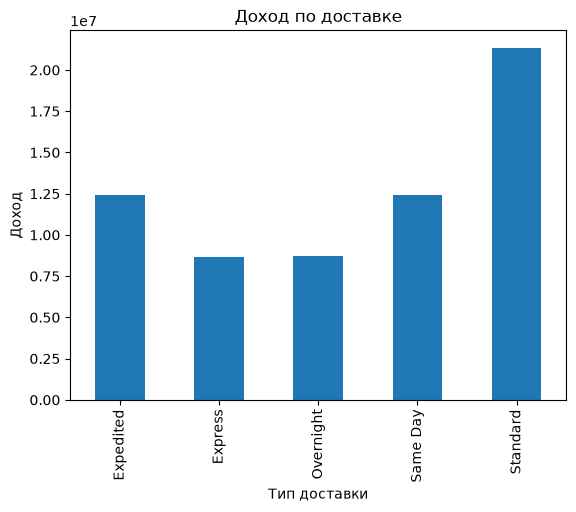

In [41]:
metrics['revenue_by_shipping'].plot.bar(
    x='Shipping Type',
    y='revenue',
    legend=False,
    title='Доход по доставке'
)

plt.xlabel('Тип доставки')
plt.ylabel('Доход')
plt.show()

#### доход по типу продукта

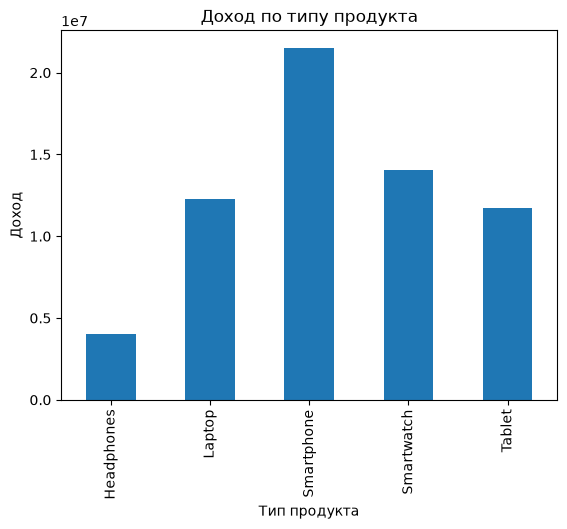

In [40]:
metrics['revenue_by_product'].plot.bar(
    x='Product Type',
    y='revenue',
    legend=False,
    title='Доход по типу продукта'
)

plt.xlabel('Тип продукта')
plt.ylabel('Доход')
plt.show()

#### доход по доп услугам по месяцам

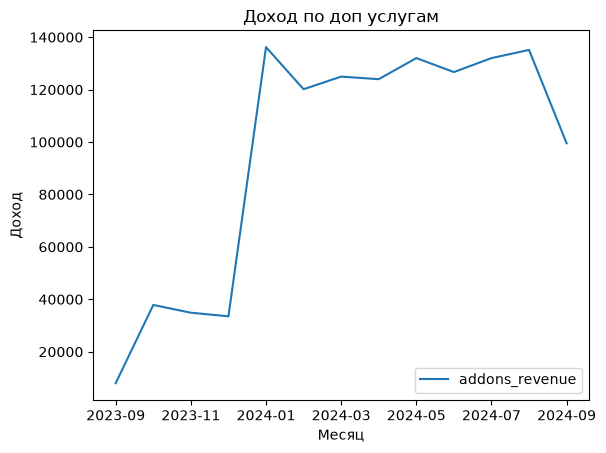

In [43]:
addons = metrics['addons_by_month'].copy()
addons['month'] = addons['month'].astype(str)

addons.plot(
    x='month',
    y='addons_revenue',
    title='Доход по доп услугам'
)

plt.xlabel('Месяц')
plt.ylabel('Доход')
plt.show()

#### когортная матрица выручки

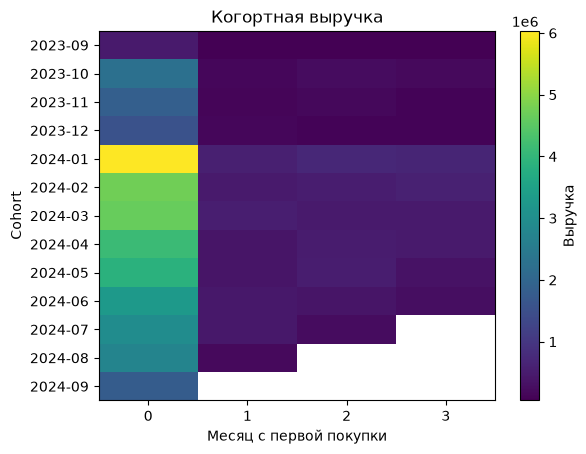

In [47]:
cohort = metrics['cohort_revenue']

fig, ax = plt.subplots()

image = ax.imshow(cohort, aspect='auto')

ax.set_xticks(range(len(cohort.columns)))
ax.set_xticklabels(cohort.columns)

ax.set_yticks(range(len(cohort.index)))
ax.set_yticklabels(cohort.index.astype(str))

ax.set_xlabel('Месяц с первой покупки')
ax.set_ylabel('Cohort')
ax.set_title('Когортная выручка')

fig.colorbar(image, ax=ax, label='Выручка')

plt.show()